Load Data

In [ ]:
import pandas as pd

df = pd.read_csv("/content/nike_shoes_dataset.csv")
df.head()

,Product_ID,Product_Name,Category,Price,Discount,Rating,Reviews_Count,Stock,Sales,Region,Date
0,1,Metcon,Training,10943,20,3.5,816,177,430,North,2024-01-01
1,2,ZoomX,Basketball,9891,10,4.9,117,133,383,South,2024-01-02
2,3,Pegasus,Basketball,9738,0,3.1,376,59,492,North,2024-01-03
3,4,ZoomX,Running,5472,20,4.1,290,171,21,South,2024-01-04
4,5,ZoomX,Training,13852,20,3.3,137,120,300,East,2024-01-05


Data Cleaning

In [ ]:
# Check nulls
df.isnull().sum()

# Convert date
df['Date'] = pd.to_datetime(df['Date'])

# Create Revenue column
df['Revenue'] = df['Price'] * df['Sales']

Key KPIs

In [ ]:
total_revenue = df['Revenue'].sum()
total_sales = df['Sales'].sum()
avg_rating = df['Rating'].mean()

print(total_revenue, total_sales, avg_rating)

1099949588 120796 3.7516


Top Products

In [ ]:
top_products = df.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False)
print(top_products)

Product_Name
Metcon        250870611
ZoomX         220804594
Air Max       220421714
Revolution    214247585
Pegasus       193605084
Name: Revenue, dtype: int64


Category Performance

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum()
print(category_sales)

Category
Basketball    25960
Lifestyle     28583
Running       33761
Training      32492
Name: Sales, dtype: int64


Monthly Trend

In [ ]:
df['Month'] = df['Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Revenue'].sum()
print(monthly_sales)

Month
2024-01    87529571
2024-02    50896633
2024-03    63090078
2024-04    75336541
2024-05    68854913
2024-06    46159190
2024-07    76087094
2024-08    76739192
2024-09    57911152
2024-10    64987973
2024-11    76842840
2024-12    70253855
2025-01    64600666
2025-02    71849340
2025-03    58049458
2025-04    69594563
2025-05    21166529
Freq: M, Name: Revenue, dtype: int64


Region-wise Analysis

In [ ]:
region_sales = df.groupby('Region')['Revenue'].sum()
print(region_sales)

Region
East     246463542
North    302450108
South    257139551
West     293896387
Name: Revenue, dtype: int64


Discount Impact

In [ ]:
discount_effect = df.groupby('Discount')['Sales'].mean()
print(discount_effect)

Discount
0     251.375000
10    243.171429
20    238.838384
30    248.775510
40    226.529412
Name: Sales, dtype: float64


Visualization

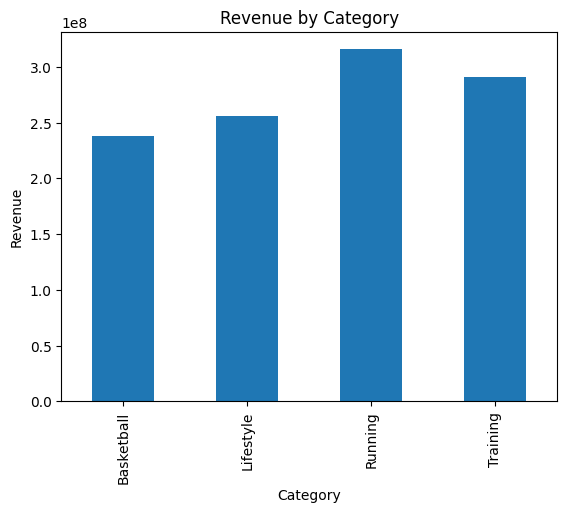

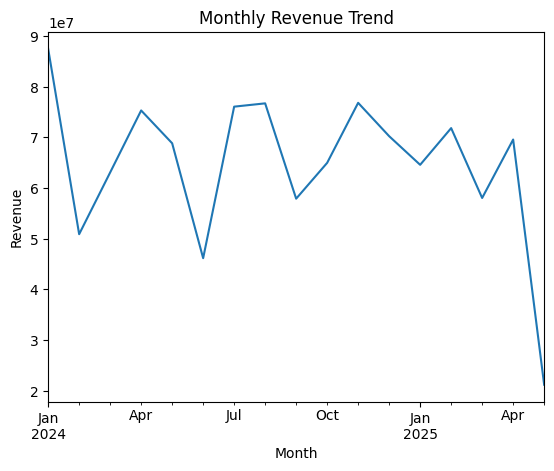

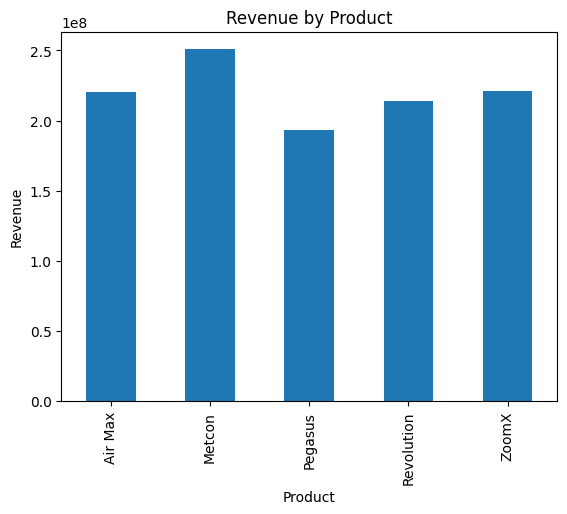

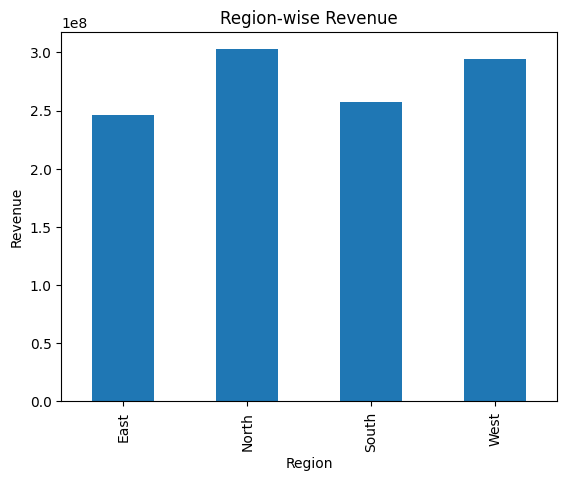

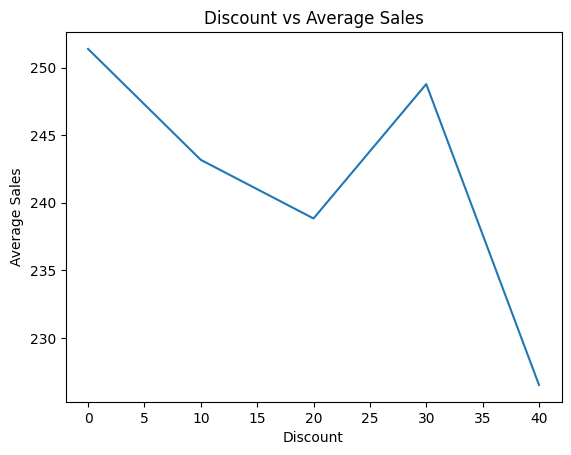

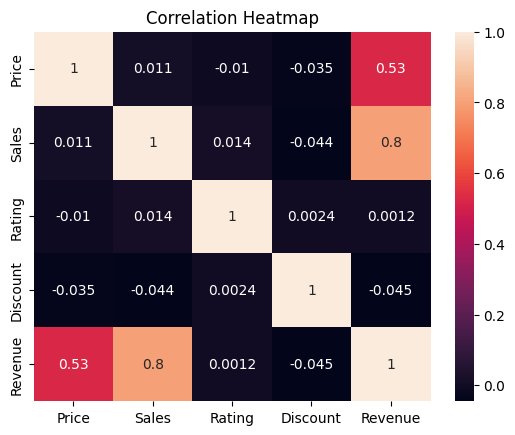

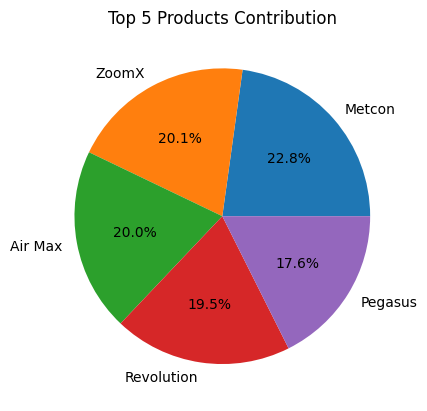

In [ ]:
import matplotlib.pyplot as plt

# Create new columns
df['Revenue'] = df['Price'] * df['Sales']

# 1. Revenue by Category
df.groupby('Category')['Revenue'].sum().plot(kind='bar')
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

# 2. Monthly Revenue Trend
df.groupby('Month')['Revenue'].sum().plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

# 3. Revenue by Product
df.groupby('Product_Name')['Revenue'].sum().plot(kind='bar')
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.show()

# 4. Region-wise Revenue
df.groupby('Region')['Revenue'].sum().plot(kind='bar')
plt.title("Region-wise Revenue")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()

# 5. Discount vs Sales
df.groupby('Discount')['Sales'].mean().plot()
plt.title("Discount vs Average Sales")
plt.xlabel("Discount")
plt.ylabel("Average Sales")
plt.show()

#Correlation Heatmap
import seaborn as sns

sns.heatmap(df[['Price','Sales','Rating','Discount','Revenue']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

#Top 5 Products Pie Chart
top5 = df.groupby('Product_Name')['Revenue'].sum().nlargest(5)
top5.plot(kind='pie', autopct='%1.1f%%')
plt.title("Top 5 Products Contribution")
plt.ylabel('')
plt.show()